In [2]:
import pandas as pd
import numpy as np

df_livraisons = pd.read_csv('deliverytime.csv')
df_meteo = pd.read_csv('weatherHistory.csv')

print("Dimensions du dataset Livraisons :", df_livraisons.shape)
print("Dimensions du dataset Météo :", df_meteo.shape)

# Afficher les premières lignes
display(df_livraisons.head(3))

Dimensions du dataset Livraisons : (45593, 11)
Dimensions du dataset Météo : (96453, 12)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26


In [3]:
# 1. Lister les colonnes pour trouver la clé de fusion
print("Colonnes Livraisons :", df_livraisons.columns.tolist())
print("\nColonnes Météo :", df_meteo.columns.tolist())

# 2. Vérifier s'il y a déjà des doublons dans la base principale
print("\nDoublons dans df_livraisons :", df_livraisons.duplicated().sum())

# 3. Vérifier les valeurs manquantes initiales
print("\nValeurs manquantes dans df_livraisons :\n", df_livraisons.isnull().sum())

Colonnes Livraisons : ['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle', 'Time_taken(min)']

Colonnes Météo : ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']

Doublons dans df_livraisons : 0

Valeurs manquantes dans df_livraisons :
 ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64


In [4]:
import pandas as pd
import numpy as np


# On force la conversion en évitant les problèmes de fuseaux horaires
df_meteo['Date'] = pd.to_datetime(df_meteo['Formatted Date'], utc=True).dt.date

# Récupérer toutes les dates uniques disponibles dans la météo
dates_meteo_uniques = df_meteo['Date'].unique()

# Assigner une de ces dates au hasard pour chaque ligne de livraison
# Cela simule le fait que les commandes ont été passées ces jours-là
np.random.seed(42) 
df_livraisons['Date'] = np.random.choice(dates_meteo_uniques, size=len(df_livraisons))

# On déduplique la météo pour n'avoir qu'une seule ligne par jour 
df_meteo_journaliere = df_meteo.drop_duplicates(subset=['Date'])

# LA FUSION FINALE
df_final = pd.merge(df_livraisons, df_meteo_journaliere, on='Date', how='left')

print("Fusion réussie ! Dimensions du nouveau dataset :", df_final.shape)

# On affiche les colonnes fusionnées pour vérifier
display(df_final[['ID', 'Date', 'Temperature (C)', 'Precip Type', 'Time_taken(min)']].head())

Fusion réussie ! Dimensions du nouveau dataset : (45593, 24)


,ID,Date,Temperature (C),Precip Type,Time_taken(min)
0,4607,2014-05-14,11.016667,rain,24
1,B379,2015-03-12,7.827778,rain,33
2,5D6D,2008-01-10,-2.211111,snow,26
3,7A6A,2009-06-17,12.788889,rain,21
4,70A2,2009-07-31,21.111111,rain,30


In [5]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Rayon de la Terre en kilomètres
    R = 6371.0
    
    # Conversion en radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Différences de coordonnées
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Formule de Haversine
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    return R * c

# Application de la fonction à notre dataframe
df_final['Distance_km'] = haversine_distance(
    df_final['Restaurant_latitude'], 
    df_final['Restaurant_longitude'], 
    df_final['Delivery_location_latitude'], 
    df_final['Delivery_location_longitude']
)

print("Aperçu des distances calculées :")
display(df_final[['Distance_km', 'Time_taken(min)']].head())

Aperçu des distances calculées :


,Distance_km,Time_taken(min)
0,3.025149,24
1,20.183530,33
2,1.552758,26
3,7.790401,21
4,6.210138,30


C:\Users\Admin\AppData\Local\Temp\ipykernel_5064\1748149091.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Precip Type', y='Time_taken(min)', data=df_final, palette='Set2')


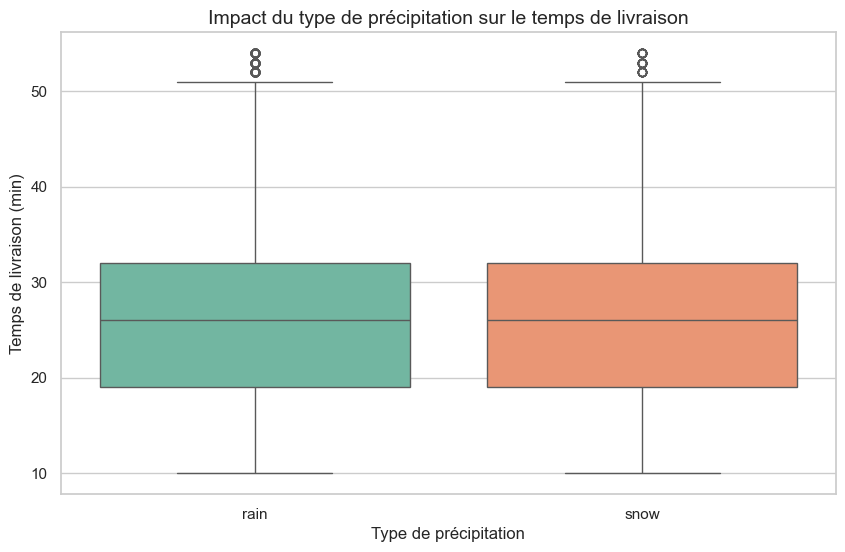

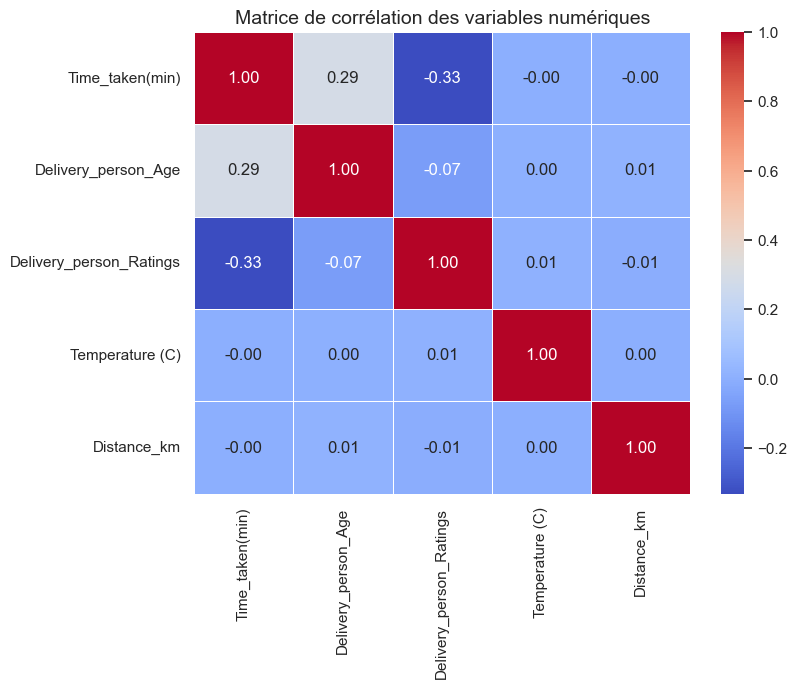

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique globale
sns.set_theme(style="whitegrid")

# 1. Boxplot : Impact de la météo sur le temps de livraison
plt.figure(figsize=(10, 6))
sns.boxplot(x='Precip Type', y='Time_taken(min)', data=df_final, palette='Set2')
plt.title('Impact du type de précipitation sur le temps de livraison', fontsize=14)
plt.ylabel('Temps de livraison (min)')
plt.xlabel('Type de précipitation')
plt.show()

# 2. Heatmap : Matrice de corrélation
plt.figure(figsize=(8, 6))
# On sélectionne quelques colonnes numériques pertinentes
cols_numeriques = ['Time_taken(min)', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Temperature (C)', 'Distance_km']

# Calcul et affichage de la corrélation
corr = df_final[cols_numeriques].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.show()

**Analyse du Boxplot :**

L'observation : Les deux boîtes à moustaches (pour la pluie et la neige) sont pratiquement identiques. La médiane se situe autour de 26 minutes pour les deux cas, et la distribution (du premier au troisième quartile, soit de ~19 à ~32 minutes) est visuellement la même. Les valeurs extrêmes (outliers) montent également jusqu'aux mêmes niveaux.

La conclusion : Contrairement à ce qu'on pourrait penser intuitivement, dans ce dataset spécifique, le type de précipitation (pluie ou neige) ne semble pas avoir d'impact significatif sur le temps de livraison global. 

**Analyse de la Heatmap :**

Corrélations avec le temps de livraison (Time_taken(min)) :

Note du livreur (Delivery_person_Ratings, corrélation de -0.33) : C'est la relation la plus forte. Elle est négative, ce qui est très logique : plus le livreur a une bonne note, moins le temps de livraison est long.

Âge du livreur (Delivery_person_Age, corrélation de 0.29) : La relation est positive. Plus le livreur est âgé, plus le temps de livraison a tendance à augmenter.

Température et Distance (Temperature (C) et Distance_km, corrélations de -0.00) : C'est la plus grosse surprise de cette analyse. Il n'y a aucune corrélation linéaire entre la distance calculée (ou la température) et le temps de livraison.

*La conclusion globale :* Pour ce dataset, les caractéristiques du livreur (son âge et ses évaluations) sont de bien meilleurs indicateurs du temps de livraison que la distance du trajet elle-même.

*Le piège de la distance :* Le fait que la distance ne soit pas corrélée au temps est étonnant. Cela pourrait signifier deux choses :

Soit la distance à vol d'oiseau que nous avons calculée n'est pas représentative du trajet réel (à cause du réseau routier).

Soit les temps d'attente au restaurant (qui sont inclus dans Time_taken(min)) sont tellement variables qu'ils "nient" l'effet de la distance du trajet.